# Recovering single-trial amplitude **and** latency with SPMG2 + the cone prior

`ffs_fitbasis -model SPMG2 -reg cone`, measured against ground truth on simulated
rapid event-related data.

## What this mode actually does

**SPMG2** gives each block two columns: the canonical HRF convolved with the
stimulus box, and its temporal derivative convolved the same way. That is a
first-order Taylor expansion of a *shifted* response,

$$A\,h(t-\tau)\;\approx\;A\,h(t)\;-\;A\tau\,h'(t)
\qquad\Rightarrow\qquad
\beta_c = A,\quad \beta_d = -A\tau .$$

So amplitude is a **coefficient** and latency is a **ratio of two coefficients**,
$\tau \propto -\beta_d/\beta_c$. That asymmetry drives everything below: a ratio
is unbounded, and it blows up whenever $\beta_c \to 0$.

**Why `-reg ridge` is the wrong prior.** It penalises
$(\beta-m)^\top C^{-1}(\beta-m)$ with a *fixed* $m$, i.e. a Gaussian on $\beta_d$ in
data units. Since $\beta_d = -A\tau$, a strong trial pays more for the same latency
than a weak one — a latency prior whose strength depends on amplitude. On FLOBS the
fixed $m$ made it an outright *amplitude* prior (the bug of record: a true peak of
3.0 came back as 1.37).

**What `-reg cone` changes.** It is filmbabe's form. Each block gets a free size
scalar $s$ that never enters the design, penalised as
$(\beta - sm)^\top P_0 (\beta - sm)/s^2$. Profiling $s$ out gives something
homogeneous of degree 0 in $\beta$:

$$\operatorname{pen}(\beta)\;=\;\|m\|^2_{P_0}\,\sin^2\theta_{P_0}(\beta, m).$$

Pure **angle**. Amplitude is entirely free and sign-free (negative BOLD keeps its
shape). For SPMG2 the prior ray $m$ points along the canonical axis, so the penalty
is on the angle — which *is* $\arctan(\beta_d/\beta_c)$, i.e. latency. It is a
latency prior that does not care about amplitude, solved by IRLS with batched
preconditioned CG.

**The catch, worked out in closed form.** For `spmg_prior`'s diagonal
$C=\operatorname{diag}(\sigma_c^2,\sigma_d^2)$ with $m=[\sigma_c,0]$, writing
$\rho=\sigma_c/\sigma_d$ and $r=\beta_d/\beta_c$:

$$\operatorname{pen}(r)\;=\;\frac{(\rho r)^2}{1+(\rho r)^2}\;\xrightarrow[\;|r|\to\infty\;]{}\;1 .$$

The penalty **saturates**. Total penalty per block is bounded by $\lambda$ no matter
how insane the ratio gets — a redescending penalty cannot restrain an unbounded
ratio. Hold on to that; it is what the measurements below land on.

## The experiment

- Rapid event-related design: 3 s stimuli, Poisson off-times of 1–5 s, 15 s lead-in
  and lead-out. Every parameter is tunable in `SimConfig`.
- **The data gets a per-trial shift; the model does not.** Each trial's response is
  displaced by $\tau_b\sim U(-1,1)$ s in microtime, but the *design* keeps the
  nominal onsets, so the ISI structure is untouched — the jitter is pure latency,
  and recovering it is the whole question.
- Per-trial amplitudes vary too, and physiological (1/f + respiratory + cardiac)
  noise plus low-frequency drift go on top.
- Three arms, all fed by the **same** microtime sampling primitive so no arm gets a
  sampling advantage: `-reg cone`, `-reg ridge`, and `-parametrization shift` (the
  slow exact-shifting path this is meant to replace).

Everything is scored on **both correlation and scale** — a latency estimator can hit
r = 0.99 and still be 3× compressed.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace

from fastfuncstuff.design.builder import legendre_polynomials
from fastfuncstuff.design.flobs import (
    fit_basis_cone_prior,
    fit_basis_constrained_ridge,
    generate_spmg_basis,
    spmg_prior,
)
from fastfuncstuff.design.hrf import get_hrf_library
from fastfuncstuff.design.shifted_hrf import build_shifted_design_bank, fit_shifted_hrf
from fastfuncstuff.simulation.noise import generate_fmri_noise

# One colour per arm, held fixed everywhere in the notebook.
C_CONE, C_RIDGE, C_SHIFT, C_TRUTH = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
ARM_COLOR = {"cone": C_CONE, "ridge": C_RIDGE, "shift": C_SHIFT}
ARM_LABEL = {"cone": "SPMG2 + cone", "ridge": "SPMG2 + ridge", "shift": "exact shift"}

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})
print("cuda:", torch.cuda.is_available())

cuda: True


## 1. Every knob in one place

`SimConfig` holds the full parameterisation — design, truth, noise, and model. Every
cell below takes a config, so any sweep is `replace(cfg, tr=2.0)`.

In [2]:
@dataclass
class SimConfig:
    # --- design (seconds) -------------------------------------------------
    tr: float = 1.0
    stim_dur: float = 3.0          # stimulus ON time
    gap_min: float = 1.0           # OFF time between offset and next onset
    gap_max: float = 5.0
    gap_lambda: float = 2.0        # Poisson mean for the off-time, clipped to [min,max]
    lead_in: float = 15.0
    lead_out: float = 15.0
    n_trials: int = 40

    # --- truth ------------------------------------------------------------
    tau_jitter: float = 1.0        # per-trial latency ~ U(-jitter, +jitter)
    amp_mean: float = 1.0          # %SC at the peak of an isolated response
    amp_spread: float = 1.0        # A ~ U(mean - spread, mean + spread)
    build_hrf: str = "canonical"   # "canonical" or "library:<k>" for build != model

    # --- noise ------------------------------------------------------------
    noise_sd: float = 0.5          # %SC  (baseline 100 -> tSNR = 100 / noise_sd)
    pink_exp: float = 1.0          # 1/f slope
    resp_strength: float = 3.0     # respiratory peak (~0.35 Hz)
    cardiac_strength: float = 5.0  # cardiac peak (~1 Hz)
    drift_sd: float = 0.5          # %SC of extra Legendre drift
    drift_degree: int = 4

    # --- model ------------------------------------------------------------
    microtime_dt: float = 0.1
    hrf_duration: float = 32.0
    polort: int = 4                # nuisance drift degree in the FIT
    canonical_std: float = 5.0     # -canonical-std
    derivative_std: float = 0.5    # -derivative-std   (rho = canonical/derivative)
    tau_max: float = 2.0           # exact-shift box bound / ratio clip
    tau_step: float = 0.25
    n_sweeps: int = 4
    delay_prior_sd: float | None = 0.75

    # --- execution --------------------------------------------------------
    n_voxels: int = 200            # independent noise realisations per condition
    seed: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    @property
    def tsnr(self):
        return 100.0 / self.noise_sd

    @property
    def rho(self):
        return self.canonical_std / self.derivative_std


cfg = SimConfig()
cfg

SimConfig(tr=1.0, stim_dur=3.0, gap_min=1.0, gap_max=5.0, gap_lambda=2.0, lead_in=15.0, lead_out=15.0, n_trials=40, tau_jitter=1.0, amp_mean=1.0, amp_spread=1.0, build_hrf='canonical', noise_sd=0.5, pink_exp=1.0, resp_strength=3.0, cardiac_strength=5.0, drift_sd=0.5, drift_degree=4, microtime_dt=0.1, hrf_duration=32.0, polort=4, canonical_std=5.0, derivative_std=0.5, tau_max=2.0, tau_step=0.25, n_sweeps=4, delay_prior_sd=0.75, n_voxels=200, seed=0, device='cuda')

## 2. Design: real timing fixed, response timing jittered

`gap` is the **off-time** — stimulus on for `stim_dur`, off for `gap`, then the next
onset. Trials never overlap in time; their HRFs of course do.

The critical split: `onsets` is what the **model** sees, `onsets + tau` is what
**built the data**.

In [3]:
def make_design(cfg, rng):
    """Nominal onsets plus the per-trial truth (tau, amplitude)."""
    onsets, t = [], cfg.lead_in
    for _ in range(cfg.n_trials):
        onsets.append(t)
        gap = float(np.clip(rng.poisson(cfg.gap_lambda), cfg.gap_min, cfg.gap_max))
        t += cfg.stim_dur + gap
    onsets = np.asarray(onsets, dtype=np.float64)
    n_t = int(np.ceil((onsets[-1] + cfg.stim_dur + cfg.lead_out) / cfg.tr))
    tau = rng.uniform(-cfg.tau_jitter, cfg.tau_jitter, size=cfg.n_trials)
    amp = rng.uniform(cfg.amp_mean - cfg.amp_spread,
                      cfg.amp_mean + cfg.amp_spread, size=cfg.n_trials)
    return onsets, tau, amp, n_t


def response_bank(onsets, hrf, cfg, n_t, device):
    """One boxcar-convolved column per trial, sampled at TR.

    Reuses ``build_shifted_design_bank`` -- the same microtime sampler the exact-
    shift fitter uses -- with a single zero shift, because the shift is baked into
    the onsets we pass.  Truth, SPMG2 design and shift design therefore all come
    off one code path and no arm gets a sampling advantage.
    """
    return build_shifted_design_bank(
        [np.array([o]) for o in onsets], hrf, cfg.microtime_dt,
        np.array([0.0]), cfg.tr, n_t,
        durations=[cfg.stim_dur] * len(onsets), device=device,
    )[:, 0, :]  # (n_trials, n_t)


def resolve_build_hrf(cfg, g_can):
    """The shape used to BUILD the data (may differ from the model's canonical)."""
    if cfg.build_hrf == "canonical":
        return g_can
    if cfg.build_hrf.startswith("library:"):
        k = int(cfg.build_hrf.split(":")[1])
        lib = get_hrf_library(mode="library", stim_duration=0.0,
                              microtime_dt=cfg.microtime_dt,
                              hrf_duration=cfg.hrf_duration).cpu().numpy()
        h = lib[k]
        return h / np.linalg.norm(h)  # match the basis rows' L2 scaling
    raise ValueError(f"unknown build_hrf {cfg.build_hrf!r}")

In [4]:
def simulate(cfg):
    """Build data (jittered onsets) and the model design (nominal onsets)."""
    rng = np.random.default_rng(cfg.seed)
    device = torch.device(cfg.device)
    onsets, tau, amp, n_t = make_design(cfg, rng)

    basis = generate_spmg_basis(n_basis=2, duration=cfg.hrf_duration, dt=cfg.microtime_dt)
    g_can, g_der = basis.basis_functions          # L2-normalised rows
    g_build = resolve_build_hrf(cfg, g_can)

    # Peak of an ISOLATED boxcar response -> amplitudes are %SC at the peak.
    peak_scale = float(response_bank(np.array([cfg.lead_in]), g_build,
                                     cfg, n_t, device).abs().max())

    # ---- TRUTH: data is built from the JITTERED onsets -------------------
    C_true = response_bank(onsets + tau, g_build, cfg, n_t, device) / peak_scale
    signal = (torch.as_tensor(amp, device=device, dtype=torch.float64) @ C_true).cpu().numpy()

    noise = generate_fmri_noise(
        tr=cfg.tr, duration_s=n_t * cfg.tr, matrix_size=(cfg.n_voxels, 1),
        pink_exp=cfg.pink_exp, resp_strength=cfg.resp_strength,
        cardiac_strength=cfg.cardiac_strength, normalize=True, device=device,
        generator=torch.Generator(device=device).manual_seed(cfg.seed),
    ).reshape(-1, cfg.n_voxels).T.cpu().numpy()
    assert noise.shape[1] >= n_t, f"noise short: {noise.shape} vs {n_t}"
    y = signal[None, :] + cfg.noise_sd * noise[:, :n_t]

    if cfg.drift_sd > 0:  # messy low-frequency stuff, on top of the 1/f
        P = legendre_polynomials(n_t, cfg.drift_degree)[:, 1:]
        y = y + rng.normal(0, cfg.drift_sd, size=(cfg.n_voxels, P.shape[1])) @ P.T

    # ---- MODEL: NOMINAL onsets, no jitter --------------------------------
    C_can = response_bank(onsets, g_can, cfg, n_t, device)
    C_der = response_bank(onsets, g_der, cfg, n_t, device)
    # block-major layout: [b0k0, b0k1, b1k0, b1k1, ...] as the solvers expect
    X = torch.stack([C_can, C_der], dim=1).permute(2, 0, 1).reshape(n_t, -1)

    return dict(cfg=cfg, onsets=onsets, tau=tau, amp=amp, n_t=n_t, y=y, signal=signal,
                basis=basis, X=X, nuis=legendre_polynomials(n_t, cfg.polort),
                peak_scale=peak_scale, g_can=g_can, g_der=g_der, g_build=g_build,
                device=device)


sim = simulate(cfg)
print(f"{sim['n_t']} TRs ({sim['n_t']*cfg.tr:.0f} s), {cfg.n_trials} trials, "
      f"mean ISI {np.diff(sim['onsets']).mean():.2f} s, tSNR {cfg.tsnr:.0f}")

240 TRs (240 s), 40 trials, mean ISI 5.31 s, tSNR 200


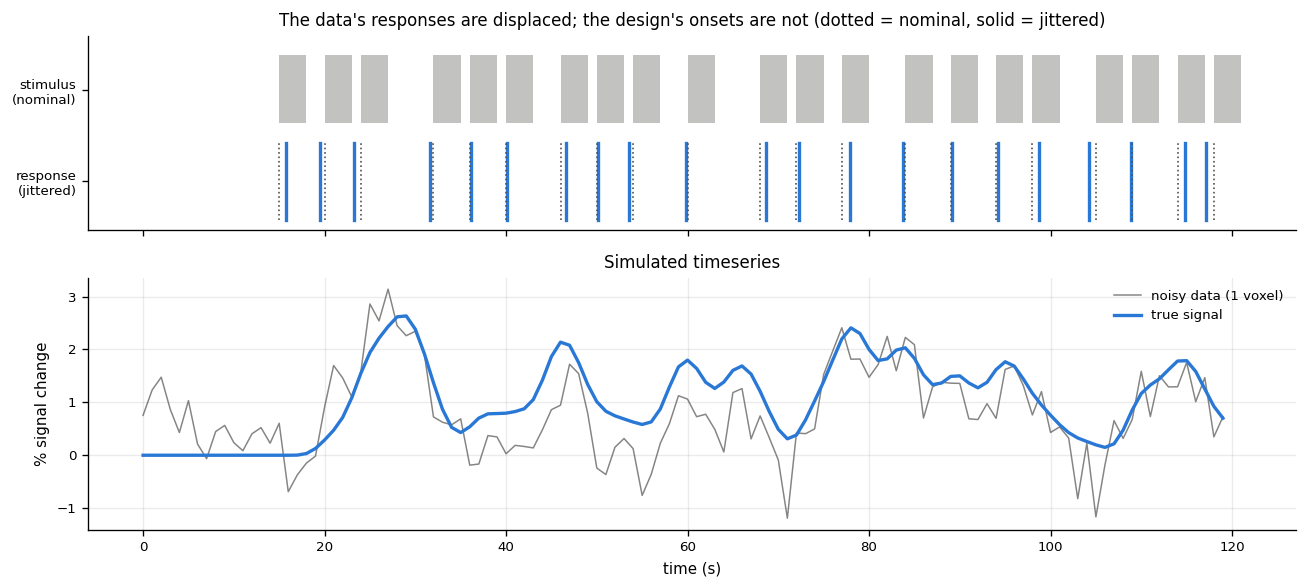

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.3]})
t = np.arange(sim["n_t"]) * cfg.tr
win = slice(0, min(sim["n_t"], int(120 / cfg.tr)))

ax = axes[0]
for i, (o, tt) in enumerate(zip(sim["onsets"], sim["tau"])):
    if o > t[win][-1]:
        break
    ax.add_patch(plt.Rectangle((o, 0.55), cfg.stim_dur, 0.35,
                               color=C_TRUTH, alpha=0.35, lw=0))
    ax.plot([o + tt, o + tt], [0.05, 0.45], color=C_CONE, lw=2)
    ax.plot([o, o], [0.05, 0.45], color=C_TRUTH, lw=1, ls=":")
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.72])
ax.set_yticklabels(["response\n(jittered)", "stimulus\n(nominal)"])
ax.set_title("The data's responses are displaced; the design's onsets are not "
             "(dotted = nominal, solid = jittered)")
ax.grid(False)

ax = axes[1]
ax.plot(t[win], sim["y"][0][win], color=C_TRUTH, lw=0.9, alpha=0.7, label="noisy data (1 voxel)")
ax.plot(t[win], sim["signal"][win], color=C_CONE, lw=2, label="true signal")
ax.set_xlabel("time (s)"); ax.set_ylabel("% signal change")
ax.legend(loc="upper right"); ax.set_title("Simulated timeseries")
fig.tight_layout()

## 3. Calibrating ratio → latency

$\tau = k\cdot(\beta_d/\beta_c)$ needs $k$, and the sign convention of SPM's
derivative is a convention rather than something to assume. So **measure the forward
map**: displace one trial at a time in noiseless data, fit with the nominal design,
and read back that trial's ratio.

One trial at a time matters. Shifting *every* trial together makes the map look like
it saturates around $|r|\approx0.32$, because a global shift is partly absorbed by
collinear neighbours — but that is not the situation the estimator is ever in.

In [6]:
def calibrate_ratio(sim, tau_probe=np.linspace(-2.5, 2.5, 21), n_probe_trials=12):
    """Noiseless forward map tau -> beta_d/beta_c, one trial displaced at a time."""
    cfg = sim["cfg"]
    Xn = sim["X"].cpu().numpy()
    picks = np.linspace(0, cfg.n_trials - 1, min(n_probe_trials, cfg.n_trials)).astype(int)
    R = np.zeros((picks.size, tau_probe.size))
    for ti, p in enumerate(tau_probe):
        for bi, b in enumerate(picks):
            ons = sim["onsets"].copy()
            ons[b] += p
            y = (response_bank(ons, sim["g_can"], cfg, sim["n_t"], sim["device"])
                 / sim["peak_scale"]).sum(0).cpu().numpy()
            bb = np.linalg.lstsq(Xn, y, rcond=None)[0].reshape(-1, 2)
            R[bi, ti] = bb[b, 1] / bb[b, 0]
    med = np.median(R, axis=0)
    near = np.abs(tau_probe) <= 0.5
    slope = np.polyfit(tau_probe[near], med[near], 1)[0]   # ratio per second
    return dict(tau=tau_probe, ratio=med, ratio_sd=R.std(0), slope=slope, k=1.0 / slope)


cal = calibrate_ratio(sim)
print(f"ratio per second = {cal['slope']:.4f}   ->   k = {cal['k']:.3f} s per unit ratio")
print(f"monotone over the probe range: {bool(np.all(np.diff(cal['ratio']) > 0))}")

ratio per second = 0.3432   ->   k = 2.914 s per unit ratio
monotone over the probe range: True


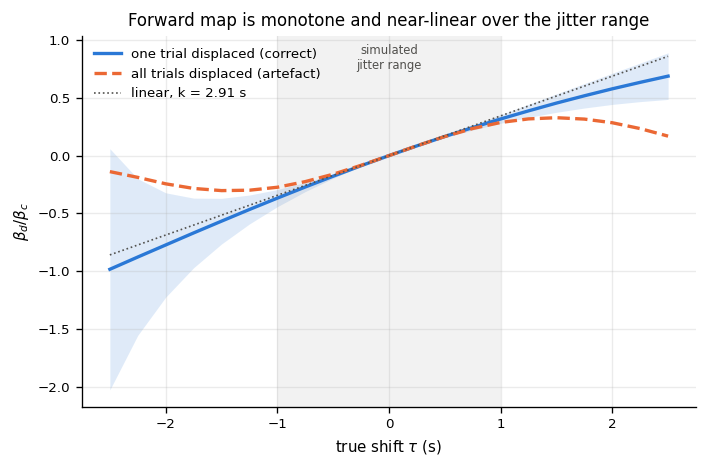

In [7]:
# The same probe done WRONG (all trials shifted together), to show the artefact.
def calibrate_global(sim, tau_probe=np.linspace(-2.5, 2.5, 21)):
    cfg, Xn = sim["cfg"], sim["X"].cpu().numpy()
    out = []
    for p in tau_probe:
        y = (response_bank(sim["onsets"] + p, sim["g_can"], cfg, sim["n_t"], sim["device"])
             / sim["peak_scale"]).sum(0).cpu().numpy()
        bb = np.linalg.lstsq(Xn, y, rcond=None)[0].reshape(-1, 2)
        out.append(np.median(bb[:, 1] / bb[:, 0]))
    return tau_probe, np.asarray(out)


gtau, gratio = calibrate_global(sim)

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(cal["tau"], cal["ratio"] - cal["ratio_sd"], cal["ratio"] + cal["ratio_sd"],
                color=C_CONE, alpha=0.15, lw=0)
ax.plot(cal["tau"], cal["ratio"], color=C_CONE, lw=2, label="one trial displaced (correct)")
ax.plot(gtau, gratio, color=C_RIDGE, lw=2, ls="--", label="all trials displaced (artefact)")
ax.plot(cal["tau"], cal["slope"] * cal["tau"], color=C_TRUTH, lw=1, ls=":",
        label=f"linear, k = {cal['k']:.2f} s")
ax.axvspan(-cfg.tau_jitter, cfg.tau_jitter, color=C_TRUTH, alpha=0.07, lw=0)
ax.annotate("simulated\njitter range", (0, ax.get_ylim()[1] * 0.72), ha="center",
            fontsize=7, color=C_TRUTH)
ax.set_xlabel(r"true shift $\tau$ (s)"); ax.set_ylabel(r"$\beta_d/\beta_c$")
ax.set_title("Forward map is monotone and near-linear over the jitter range")
ax.legend(loc="upper left")
fig.tight_layout()

The correct map is **monotone and near-linear across the whole ±2.5 s probe**, so the
Taylor linearisation is *not* the binding constraint at ±1 s of jitter. Whatever goes
wrong below is not the basis running out of validity — it is the ratio's noise
behaviour.

## 4. The three arms

`cone` and `ridge` differ only in the prior handed to the solver — exactly what
`ffs_fitbasis -reg` switches between (`cli/fitbasis.py:_build_prior`). For the cone,
`spmg_prior` centres at the origin, which leaves no ray, so `m` is pointed along the
canonical axis.

Amplitude is read the way the CLI reads it: the signed peak of the reconstructed
$\beta_c g_c + \beta_d g_d$, converted back to %SC of an isolated boxcar response.

In [8]:
def signed_peak(h):
    """Peak preserving sign -- an inverted response must report negative."""
    idx = np.argmax(np.abs(h), axis=-1, keepdims=True)
    return np.take_along_axis(h, idx, axis=-1).squeeze(-1)


def fit_arms(sim, cal, arms=("cone", "ridge", "shift")):
    cfg = sim["cfg"]
    m_ridge, C = spmg_prior(canonical_std=cfg.canonical_std,
                            derivative_std=cfg.derivative_std)
    m_cone = np.array([cfg.canonical_std, 0.0])   # the prior ray
    # impulse-response peak -> %SC of the isolated boxcar response
    conv = sim["peak_scale"] / float(np.abs(sim["g_can"]).max())
    out = {}

    for name, fn, prior_m in (("cone", fit_basis_cone_prior, m_cone),
                              ("ridge", fit_basis_constrained_ridge, m_ridge)):
        if name not in arms:
            continue
        fit = fn(data=sim["y"], design_task=sim["X"],
                 basis_functions=sim["basis"].basis_functions,
                 prior_mean=prior_m, prior_cov=C, n_blocks=cfg.n_trials,
                 nuisance=sim["nuis"], device=sim["device"])
        bt = fit.betas[:, : 2 * cfg.n_trials].reshape(-1, cfg.n_trials, 2)
        ratio = bt[..., 1] / bt[..., 0]
        out[name] = dict(amp=signed_peak(bt @ sim["basis"].basis_functions) * conv,
                         ratio=ratio, tau=cal["k"] * ratio, r2=fit.r2)

    if "shift" in arms:
        sh = fit_shifted_hrf(
            sim["y"], [np.array([o]) for o in sim["onsets"]], sim["g_can"],
            cfg.microtime_dt, cfg.tr, nuisance=sim["nuis"],
            tau_max=cfg.tau_max, tau_step=cfg.tau_step,
            durations=[cfg.stim_dur] * cfg.n_trials, n_sweeps=cfg.n_sweeps,
            delay_prior_sd=cfg.delay_prior_sd, device=sim["device"])
        out["shift"] = dict(amp=sh.amplitudes * sim["peak_scale"], ratio=None,
                            tau=sh.delays, r2=sh.r2)
    return out


res = fit_arms(sim, cal)
for k, v in res.items():
    print(f"{ARM_LABEL[k]:16s} median R2 = {np.median(v['r2']):.3f}")

SPMG2 + cone     median R2 = 0.892
SPMG2 + ridge    median R2 = 0.893
exact shift      median R2 = 0.801


## 5. Scoring — correlation *and* scale

A latency estimator can correlate at 0.99 with truth and still be 3× compressed
(that exact trap is recorded in the wiki note for this tool), so every score reports
`slope` alongside `r`.

In [9]:
def score(truth_per_trial, est, mask=None):
    """est is (n_vox, n_trials); truth is (n_trials,) broadcast across voxels."""
    T = np.broadcast_to(np.asarray(truth_per_trial), est.shape)
    ok = np.isfinite(est)
    if mask is not None:
        ok = ok & mask
    if ok.sum() < 10:
        return dict(r=np.nan, slope=np.nan, rmse=np.nan, n=int(ok.sum()))
    x, y = T[ok], est[ok]
    return dict(r=float(np.corrcoef(x, y)[0, 1]),
                slope=float(np.polyfit(x, y, 1)[0]),
                rmse=float(np.sqrt(np.mean((y - x) ** 2))),
                n=int(ok.sum()))


def summarise(sim, res, tau_clip=None):
    """tau_clip: bound the ratio-derived latency, the way tau_max bounds the shift arm."""
    cfg = sim["cfg"]
    tau_clip = cfg.tau_max if tau_clip is None else tau_clip
    rows = []
    for name, r in res.items():
        tau_raw = r["tau"]
        tau_cl = np.clip(tau_raw, -tau_clip, tau_clip)
        a = score(sim["amp"], r["amp"])
        strong = np.abs(r["amp"]) > np.median(np.abs(r["amp"]))
        rows.append(dict(
            arm=name,
            amp_r=a["r"], amp_slope=a["slope"], amp_rmse=a["rmse"],
            tau_r_raw=score(sim["tau"], tau_raw)["r"],
            tau_rmse_raw=score(sim["tau"], tau_raw)["rmse"],
            tau_r=score(sim["tau"], tau_cl)["r"],
            tau_slope=score(sim["tau"], tau_cl)["slope"],
            tau_rmse=score(sim["tau"], tau_cl)["rmse"],
            tau_r_strong=score(sim["tau"], tau_cl, mask=strong)["r"],
        ))
    return rows


def show(rows):
    hdr = (f"{'arm':16s} | {'amp r':>6s} {'slope':>6s} {'rmse':>6s} | "
           f"{'tau r':>6s} {'(raw)':>7s} {'slope':>6s} {'rmse':>6s} {'r|strong':>9s}")
    print(hdr); print("-" * len(hdr))
    for r in rows:
        print(f"{ARM_LABEL[r['arm']]:16s} | {r['amp_r']:6.3f} {r['amp_slope']:6.3f} "
              f"{r['amp_rmse']:6.3f} | {r['tau_r']:6.3f} {r['tau_r_raw']:7.3f} "
              f"{r['tau_slope']:6.3f} {r['tau_rmse']:6.3f} {r['tau_r_strong']:9.3f}")


show(summarise(sim, res))

arm              |  amp r  slope   rmse |  tau r   (raw)  slope   rmse  r|strong
--------------------------------------------------------------------------------
SPMG2 + cone     |  0.581  1.026  0.833 |  0.246   0.001  0.539  1.260     0.348
SPMG2 + ridge    |  0.614  1.035  0.770 |  0.247   0.007  0.576  1.332     0.380
exact shift      |  0.702  0.983  0.643 |  0.401   0.401  0.282  0.566     0.545


Read the two latency columns together. `tau r` clips the ratio-derived latency to
`tau_max` — the same box bound the exact-shift arm gets for free — and `(raw)` is the
unclipped ratio. The gap between them is the entire story of this mode.

## 6. Where the ratio goes wrong

Unbounded ratio, unbounded damage: a handful of trials with $\beta_c\to 0$ produce
latencies of tens of seconds and dominate the correlation.

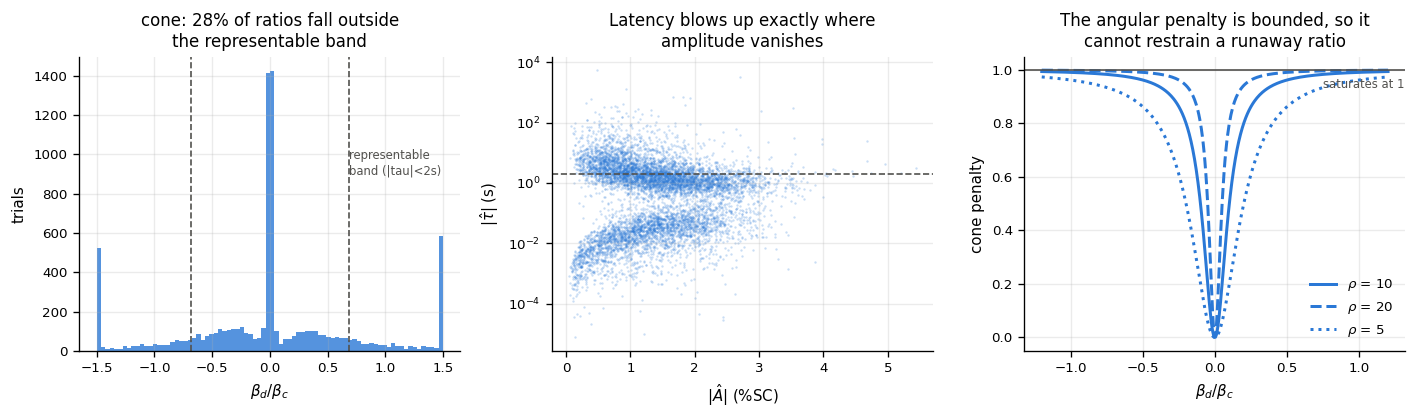

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

ax = axes[0]
r = res["cone"]["ratio"].ravel()
lim = cal["slope"] * cfg.tau_max
ax.hist(np.clip(r, -1.5, 1.5), bins=80, color=C_CONE, alpha=0.8, lw=0)
ax.axvline(lim, color=C_TRUTH, ls="--", lw=1)
ax.axvline(-lim, color=C_TRUTH, ls="--", lw=1)
ax.annotate(f"representable\nband (|tau|<{cfg.tau_max:.0f}s)", (lim, ax.get_ylim()[1] * 0.6),
            fontsize=7, color=C_TRUTH, ha="left")
frac = float(np.mean(np.abs(r) > lim))
ax.set_title(f"cone: {100*frac:.0f}% of ratios fall outside\nthe representable band")
ax.set_xlabel(r"$\beta_d/\beta_c$"); ax.set_ylabel("trials")

ax = axes[1]
ax.scatter(np.abs(res["cone"]["amp"]).ravel(), np.abs(res["cone"]["tau"]).ravel(),
           s=2, alpha=0.25, color=C_CONE, lw=0)
ax.set_yscale("log"); ax.set_xlabel(r"$|\hat{A}|$ (%SC)")
ax.set_ylabel(r"$|\hat{\tau}|$ (s)")
ax.axhline(cfg.tau_max, color=C_TRUTH, ls="--", lw=1)
ax.set_title("Latency blows up exactly where\namplitude vanishes")

ax = axes[2]
rr = np.linspace(-1.2, 1.2, 400)
for rho, ls in ((cfg.rho, "-"), (2 * cfg.rho, "--"), (0.5 * cfg.rho, ":")):
    ax.plot(rr, (rho * rr) ** 2 / (1 + (rho * rr) ** 2), color=C_CONE, ls=ls, lw=1.8,
            label=fr"$\rho$ = {rho:.0f}")
ax.axhline(1.0, color=C_TRUTH, lw=1, ls="-")
ax.annotate("saturates at 1", (0.75, 0.93), fontsize=7, color=C_TRUTH)
ax.set_xlabel(r"$\beta_d/\beta_c$"); ax.set_ylabel("cone penalty")
ax.set_title("The angular penalty is bounded, so it\ncannot restrain a runaway ratio")
ax.legend(loc="lower right")
fig.tight_layout()

Those three panels are one argument. The cone penalty saturates, so past a modest
ratio it exerts no further pull; the ratio explodes precisely where $\beta_c\to0$;
and a large fraction of trials land outside the band any real latency could occupy.

**The fix is the one the exact-shift path already has: a box bound.** Clipping the
ratio to $|\tau|\le$ `tau_max` costs nothing and discards only values that were never
physically representable.

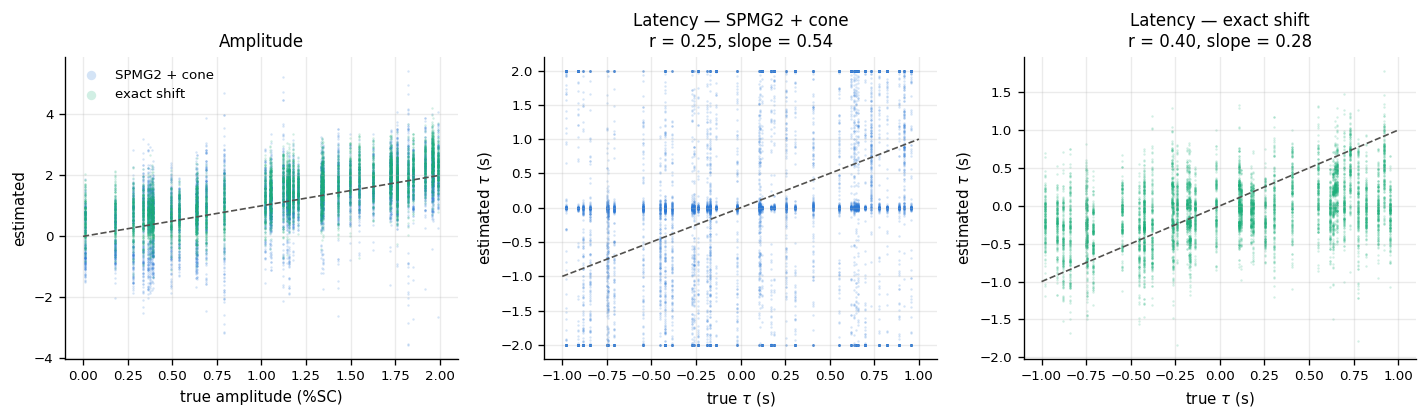

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
T = np.broadcast_to(sim["tau"], res["cone"]["tau"].shape)

ax = axes[0]
for name in ("cone", "shift"):
    ax.scatter(np.broadcast_to(sim["amp"], res[name]["amp"].shape).ravel(),
               res[name]["amp"].ravel(), s=2, alpha=0.2,
               color=ARM_COLOR[name], lw=0, label=ARM_LABEL[name])
lo, hi = cfg.amp_mean - cfg.amp_spread, cfg.amp_mean + cfg.amp_spread
ax.plot([lo, hi], [lo, hi], color=C_TRUTH, lw=1, ls="--")
ax.set_xlabel("true amplitude (%SC)"); ax.set_ylabel("estimated")
ax.set_title("Amplitude"); ax.legend(markerscale=4, loc="upper left")

for ax, name in zip(axes[1:], ("cone", "shift")):
    est = np.clip(res[name]["tau"], -cfg.tau_max, cfg.tau_max)
    ax.scatter(T.ravel(), est.ravel(), s=2, alpha=0.2, color=ARM_COLOR[name], lw=0)
    ax.plot([-cfg.tau_jitter, cfg.tau_jitter], [-cfg.tau_jitter, cfg.tau_jitter],
            color=C_TRUTH, lw=1, ls="--")
    s = score(sim["tau"], est)
    ax.set_xlabel(r"true $\tau$ (s)"); ax.set_ylabel(r"estimated $\tau$ (s)")
    ax.set_title(f"Latency — {ARM_LABEL[name]}\nr = {s['r']:.2f}, slope = {s['slope']:.2f}")
fig.tight_layout()

## 7. Sweeps

The point of the whole exercise: where in (TR, tSNR, jitter) does this mode work?
Each cell redraws the design `n_designs` times so the numbers are not one lucky
layout, and each design carries `n_voxels` independent noise realisations.

noise_sd:   0%|          | 0/18 [00:00<?, ?it/s]

37 s


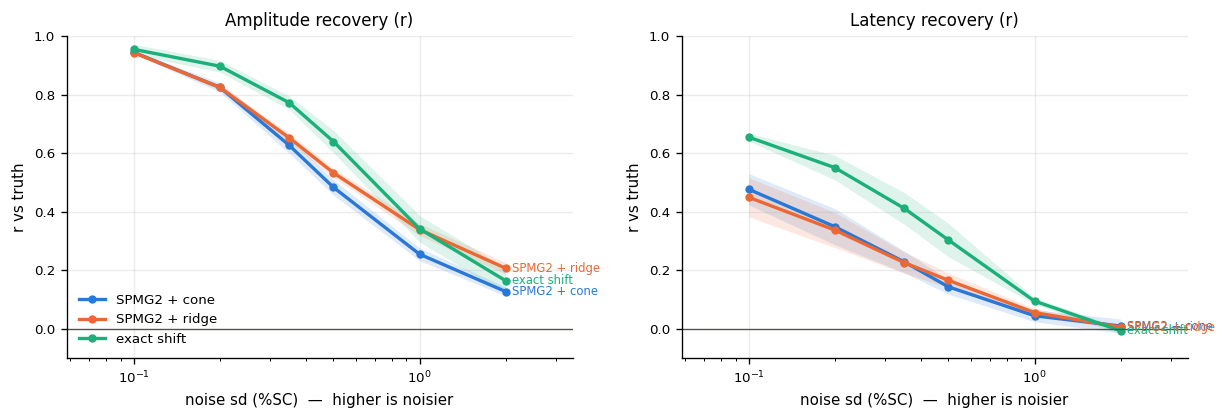

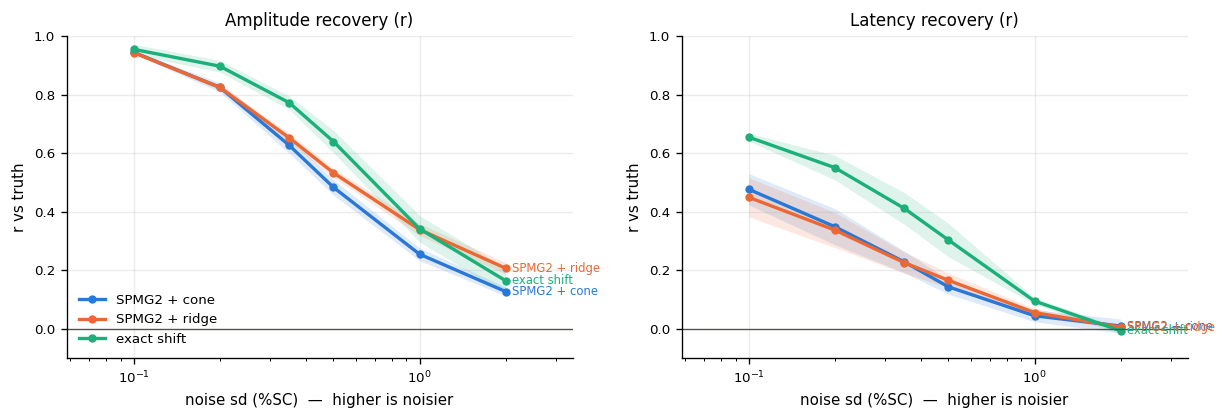

In [12]:
import itertools, time
from tqdm.auto import tqdm


def run_grid(base, axis_name, values, n_designs=3, arms=("cone", "ridge", "shift")):
    """Sweep one config field, averaging over redrawn designs."""
    rows = []
    total = len(values) * n_designs
    for v, d in tqdm(list(itertools.product(values, range(n_designs))),
                     total=total, desc=axis_name, leave=True):
        c = replace(base, **{axis_name: v}, seed=1000 * d + 7)
        s = simulate(c)
        cl = calibrate_ratio(s, n_probe_trials=6)
        for row in summarise(s, fit_arms(s, cl, arms=arms)):
            row[axis_name] = v
            row["design"] = d
            rows.append(row)
    return rows


def agg(rows, axis_name, metric):
    """-> {arm: (values, mean, sd)}"""
    out = {}
    for arm in dict.fromkeys(r["arm"] for r in rows):
        vals = sorted({r[axis_name] for r in rows if r["arm"] == arm})
        mu = [np.nanmean([r[metric] for r in rows
                          if r["arm"] == arm and r[axis_name] == v]) for v in vals]
        sd = [np.nanstd([r[metric] for r in rows
                         if r["arm"] == arm and r[axis_name] == v]) for v in vals]
        out[arm] = (np.array(vals), np.array(mu), np.array(sd))
    return out


def plot_sweep(rows, axis_name, xlabel, metrics=("amp_r", "tau_r"),
               titles=("Amplitude recovery (r)", "Latency recovery (r)"), logx=False):
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.2 * len(metrics), 3.6))
    axes = np.atleast_1d(axes)
    for ax, metric, title in zip(axes, metrics, titles):
        for arm, (x, mu, sd) in agg(rows, axis_name, metric).items():
            ax.fill_between(x, mu - sd, mu + sd, color=ARM_COLOR[arm], alpha=0.15, lw=0)
            ax.plot(x, mu, color=ARM_COLOR[arm], lw=2, marker="o", ms=4,
                    label=ARM_LABEL[arm])
            ax.annotate(ARM_LABEL[arm], (x[-1], mu[-1]), color=ARM_COLOR[arm],
                        fontsize=7, xytext=(4, 0), textcoords="offset points", va="center")
        if logx:
            ax.set_xscale("log")
        ax.axhline(0, color=C_TRUTH, lw=0.8)
        ax.set_xlabel(xlabel); ax.set_ylabel("r vs truth"); ax.set_title(title)
        ax.set_ylim(-0.1, 1.0)
        ax.margins(x=0.18)
    axes[0].legend(loc="lower left")
    fig.tight_layout()
    return fig


SWEEP = replace(cfg, n_voxels=120, n_trials=35)
t0 = time.time()
rows_noise = run_grid(SWEEP, "noise_sd", [0.1, 0.2, 0.35, 0.5, 1.0, 2.0])
print(f"{time.time()-t0:.0f} s")
plot_sweep(rows_noise, "noise_sd", "noise sd (%SC)  —  higher is noisier", logx=True)

tr:   0%|          | 0/18 [00:00<?, ?it/s]

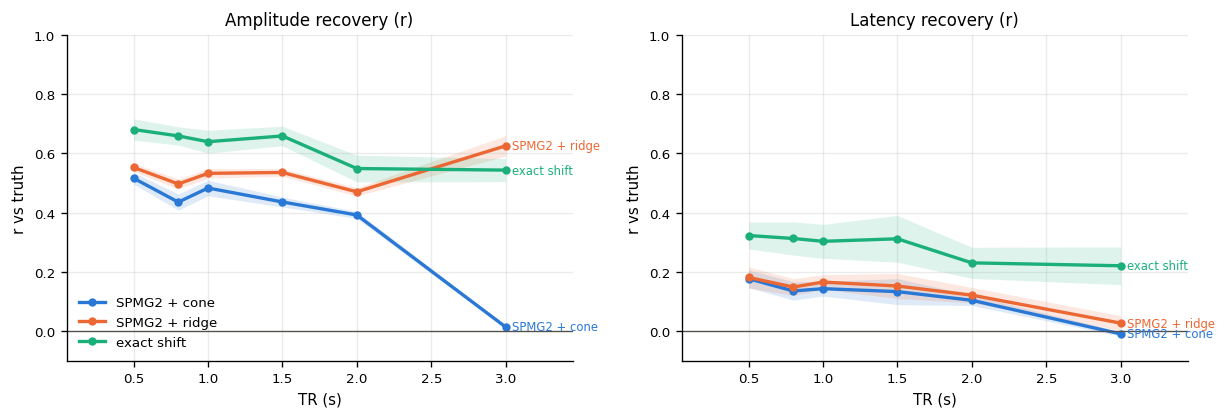

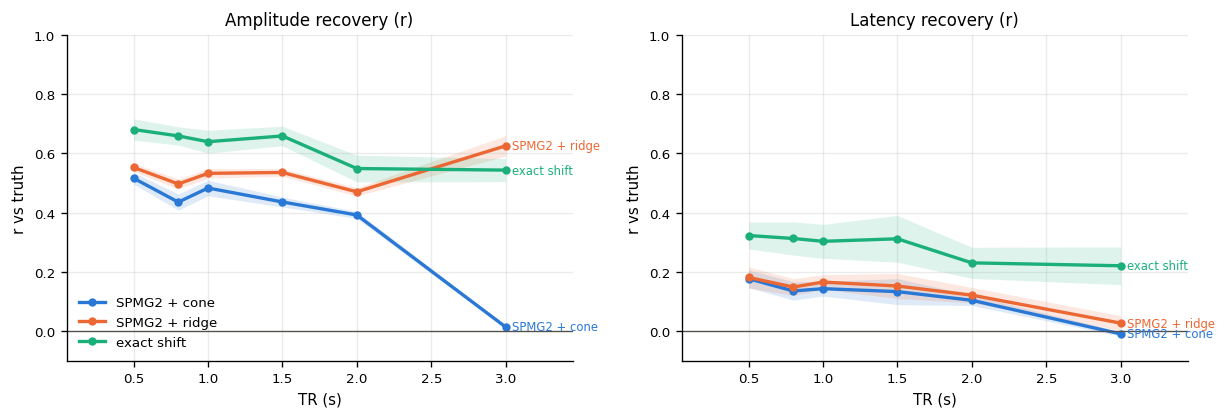

In [13]:
rows_tr = run_grid(SWEEP, "tr", [0.5, 0.8, 1.0, 1.5, 2.0, 3.0])
plot_sweep(rows_tr, "tr", "TR (s)")

tau_jitter:   0%|          | 0/15 [00:00<?, ?it/s]

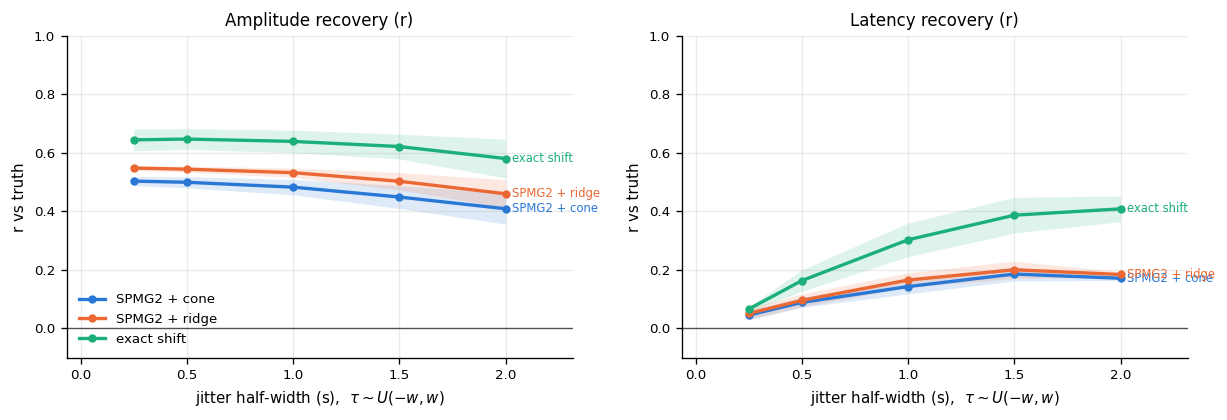

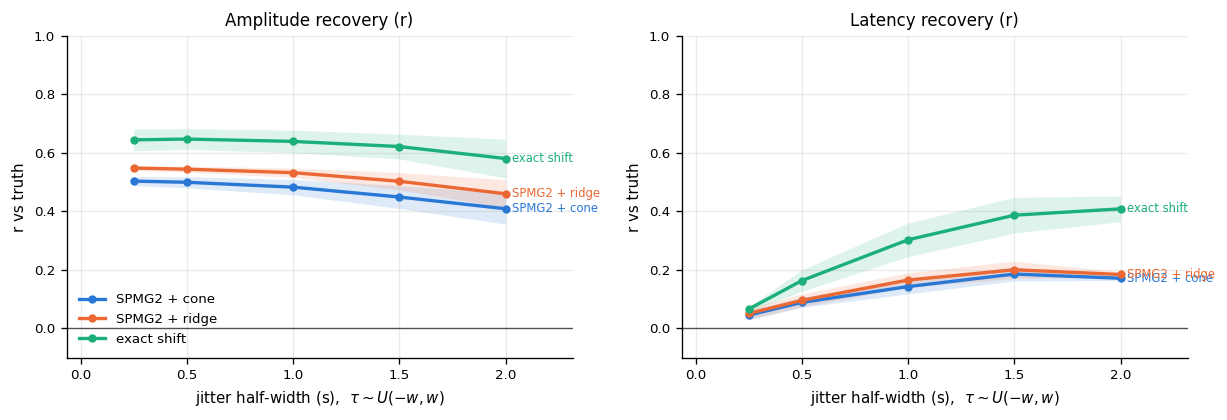

In [14]:
rows_jit = run_grid(SWEEP, "tau_jitter", [0.25, 0.5, 1.0, 1.5, 2.0])
plot_sweep(rows_jit, "tau_jitter", r"jitter half-width (s),  $\tau \sim U(-w, w)$")

derivative_std:   0%|          | 0/15 [00:00<?, ?it/s]

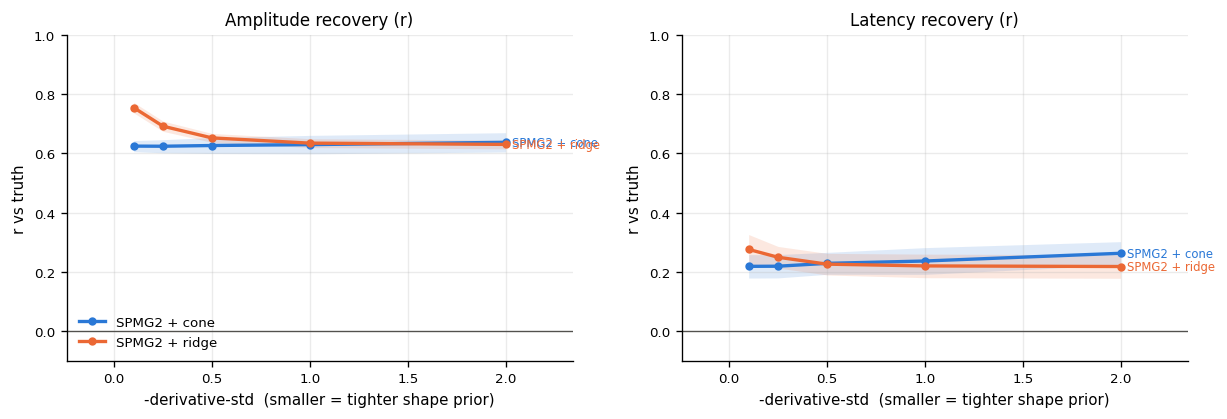

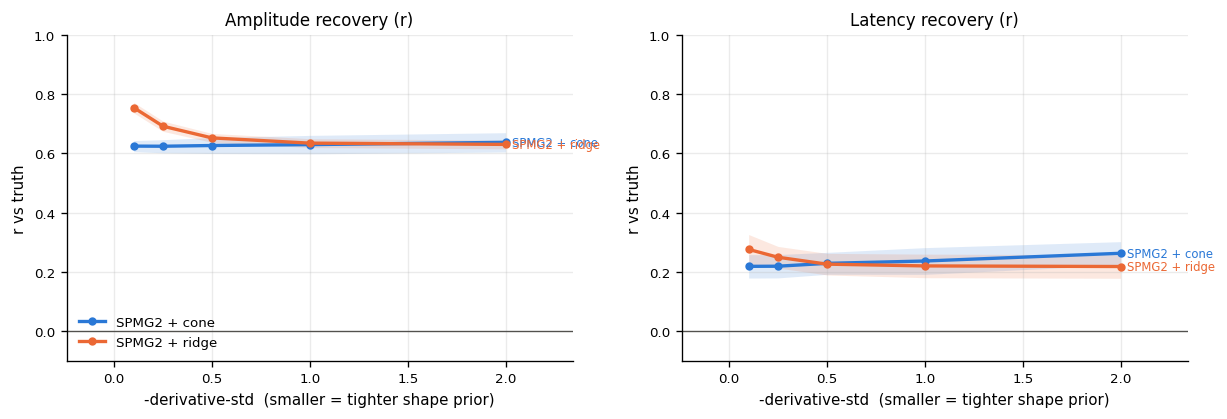

In [15]:
rows_dstd = run_grid(replace(SWEEP, noise_sd=0.35), "derivative_std",
                     [0.1, 0.25, 0.5, 1.0, 2.0], arms=("cone", "ridge"))
plot_sweep(rows_dstd, "derivative_std",
           r"-derivative-std  (smaller = tighter shape prior)")

`-derivative-std` is the only shape knob the cone has: it sets $\rho$, and therefore
where the saturating penalty turns over. If no setting of it produces a usable
latency, then the knob is not the problem — the parameterisation is.

## 8. Build ≠ model

Everything so far built the data with the same canonical the model fits. Real voxels
do not oblige. Rebuild with library HRFs while the model stays canonical, so shape
mismatch has somewhere to go — and note that a library curve with a different
time-to-peak is *itself* a latency, which the fit cannot separate from the jitter.

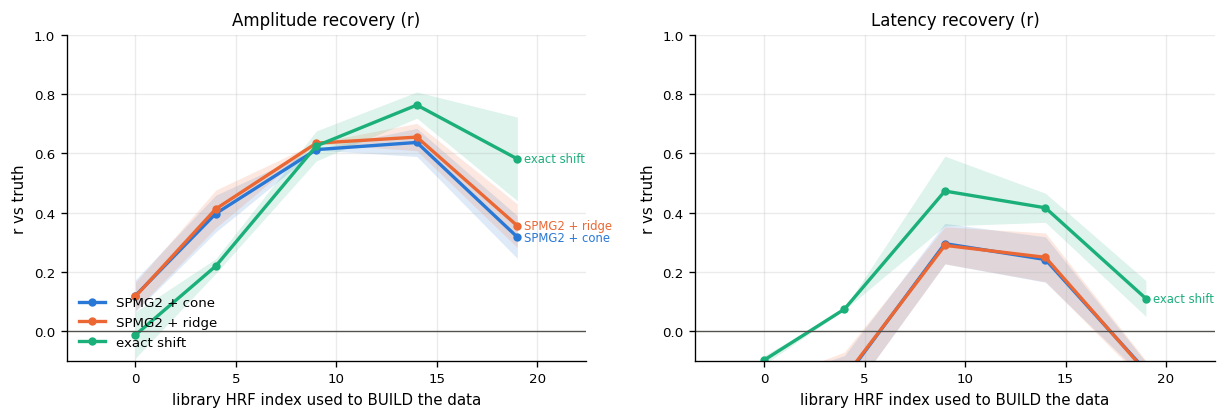

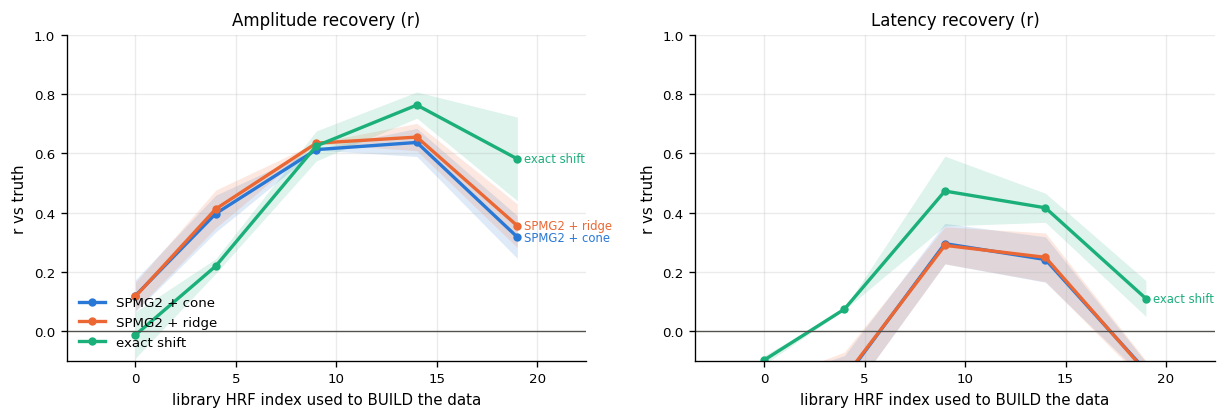

In [16]:
rows_hrf = []
for k in [0, 4, 9, 14, 19]:
    for d in range(2):
        c = replace(SWEEP, build_hrf=f"library:{k}", noise_sd=0.35, seed=1000 * d + 7)
        s = simulate(c)
        cl = calibrate_ratio(s, n_probe_trials=6)
        for row in summarise(s, fit_arms(s, cl)):
            row["hrf"] = k
            rows_hrf.append(row)

plot_sweep(rows_hrf, "hrf", "library HRF index used to BUILD the data")

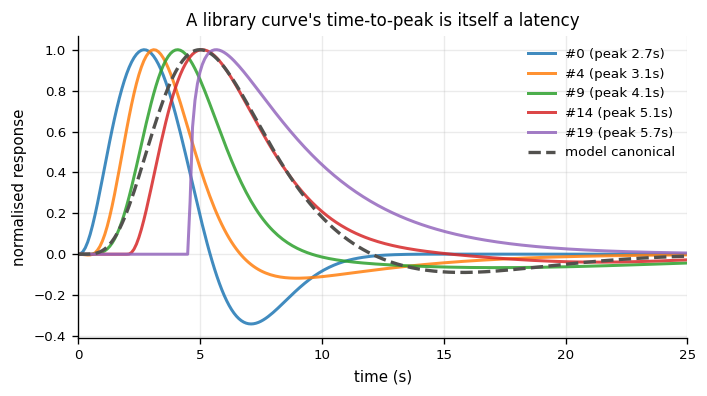

In [17]:
# Where each library curve peaks -- the confound in one picture.
lib = get_hrf_library(mode="library", stim_duration=0.0, microtime_dt=cfg.microtime_dt,
                      hrf_duration=cfg.hrf_duration).cpu().numpy()
th = np.arange(lib.shape[1]) * cfg.microtime_dt
fig, ax = plt.subplots(figsize=(6, 3.4))
for k in [0, 4, 9, 14, 19]:
    h = lib[k] / np.abs(lib[k]).max()
    ax.plot(th, h, lw=1.8, alpha=0.85, label=f"#{k} (peak {th[np.argmax(h)]:.1f}s)")
ax.plot(th, sim["g_can"] / np.abs(sim["g_can"]).max(), color=C_TRUTH, lw=2, ls="--",
        label="model canonical")
ax.set_xlim(0, 25); ax.set_xlabel("time (s)"); ax.set_ylabel("normalised response")
ax.set_title("A library curve's time-to-peak is itself a latency")
ax.legend(loc="upper right")
fig.tight_layout()

## 9. Bounds beat penalties — and when even bounds cannot help

The complaint that motivates all of this: single-trial SPMG2 amplitudes and delays go
haywire. But there *are* rules. At the condition level a voxel is "about 4 %, give or
take", and a delay cannot be 3 s — especially once the voxel's own HRF has been
identified. So the ratio **is** bounded; the parameter space is large and awkward but
real. The question is how to impose that.

A **penalty** and a **bound** are not the same tool. A quadratic penalty can only
*pull*, and the cone's angular penalty cannot even do that once it saturates — so the
runaway region stays reachable, just slightly expensive. A bound makes it
**unreachable**. That is why `-parametrization shift` does not explode: $\tau$ is a
box-bounded coordinate and $A$ is profiled out by an exact linear solve, so there is
no configuration of the data that can produce a 30 s delay.

Below, three estimators built from the *same* cone fit:

- **raw ratio** — what the tool reports today;
- **clip** — bound the ratio at $\tau_{max}$, nothing else;
- **EB** — bound it, then shrink each trial toward the voxel's own mean with
  precision weights from the delta-method variance
  $\operatorname{Var}(r_b)\approx\sigma^2[(X^\top X)^{-1}]_{dd}/\beta_{c,b}^2$.
  This is the ratio-space analogue of the `delay_prior_sd` that the shift path
  already has, and it encodes exactly "this voxel's delays are similar trial to
  trial".

In [18]:
def ratio_estimators(sim, cal, cfg, prior_sd_ratio=None):
    # Bounded / empirical-Bayes latency, from a single cone fit.
    m_ridge, C = spmg_prior(canonical_std=cfg.canonical_std,
                            derivative_std=cfg.derivative_std)
    fit = fit_basis_cone_prior(
        data=sim['y'], design_task=sim['X'],
        basis_functions=sim['basis'].basis_functions,
        prior_mean=np.array([cfg.canonical_std, 0.0]), prior_cov=C,
        n_blocks=cfg.n_trials, nuisance=sim['nuis'], device=sim['device'])
    bt = fit.betas[:, :2 * cfg.n_trials].reshape(-1, cfg.n_trials, 2)
    ratio, bc = bt[..., 1] / bt[..., 0], bt[..., 0]

    # delta-method standard error of each trial's ratio
    Xf = np.concatenate([sim['X'].cpu().numpy(), sim['nuis']], axis=1)
    cdd = np.diag(np.linalg.pinv(Xf.T @ Xf))[1:2 * cfg.n_trials:2]
    resid = sim['y'] - fit.betas @ Xf.T
    sig2 = (resid ** 2).sum(1) / (sim['n_t'] - Xf.shape[1])
    var_ratio = (sig2[:, None] * cdd[None, :]) / np.maximum(bc ** 2, 1e-12)
    w = 1.0 / np.maximum(var_ratio, 1e-12)

    rmax = cfg.tau_max / cal['k']                     # the representable band
    prior_sd_ratio = 0.5 * rmax if prior_sd_ratio is None else prior_sd_ratio
    lam = 1.0 / prior_sd_ratio ** 2
    rc = np.clip(ratio, -rmax, rmax)
    mu = (w * rc).sum(1, keepdims=True) / w.sum(1, keepdims=True)
    eb = np.clip((w * ratio + lam * mu) / (w + lam), -rmax, rmax)

    return dict(raw=cal['k'] * ratio, clip=cal['k'] * rc, eb=cal['k'] * eb,
                se_ratio=np.sqrt(var_ratio), rmax=rmax)


est = ratio_estimators(sim, cal, cfg)
print(f"representable band |ratio| <= {est['rmax']:.3f}   "
      f"median SE(ratio) = {np.median(est['se_ratio']):.3f}\n")
print(f"{'estimator':22s} {'r':>7s} {'slope':>7s} {'rmse':>9s}")
print('-' * 48)
for nm, e in (('cone: raw ratio', est['raw']), ('cone: clipped', est['clip']),
              ('cone: bounded + EB', est['eb']), ('exact shift', res['shift']['tau'])):
    s = score(sim['tau'], e)
    print(f"{nm:22s} {s['r']:+7.3f} {s['slope']:+7.3f} {s['rmse']:9.3f}")

representable band |ratio| <= 0.686   median SE(ratio) = 0.462

estimator                    r   slope      rmse
------------------------------------------------
cone: raw ratio         +0.001  +0.076    77.320
cone: clipped           +0.246  +0.539     1.260
cone: bounded + EB      +0.319  +0.284     0.645
exact shift             +0.401  +0.282     0.566


### The feasibility criterion

The last diagnostic is the useful one, and it needs no ground truth. Each trial's
ratio has a standard error
$\operatorname{SE}(r_b)=\sigma\sqrt{[(X^\top X)^{-1}]_{dd}}\,/\,|\beta_{c,b}|$, and
the physically representable band is $|r|\le\tau_{max}/k$. When

$$\operatorname{SE}(r_b)\;\gtrsim\;\tau_{max}/k$$

the likelihood is essentially **flat across the entire feasible range** — that trial's
latency is not weakly identified, it is not identified at all. No estimator can fix
that: bounded, penalised, or fully nonlinear, they will all return the prior. The only
remedies are more signal or fewer parameters (pool trials toward the condition level).

This is computable from the design and a variance estimate *before* committing to any
fit, which makes it the thing to check first on real data.

feasibility:   0%|          | 0/8 [00:00<?, ?it/s]

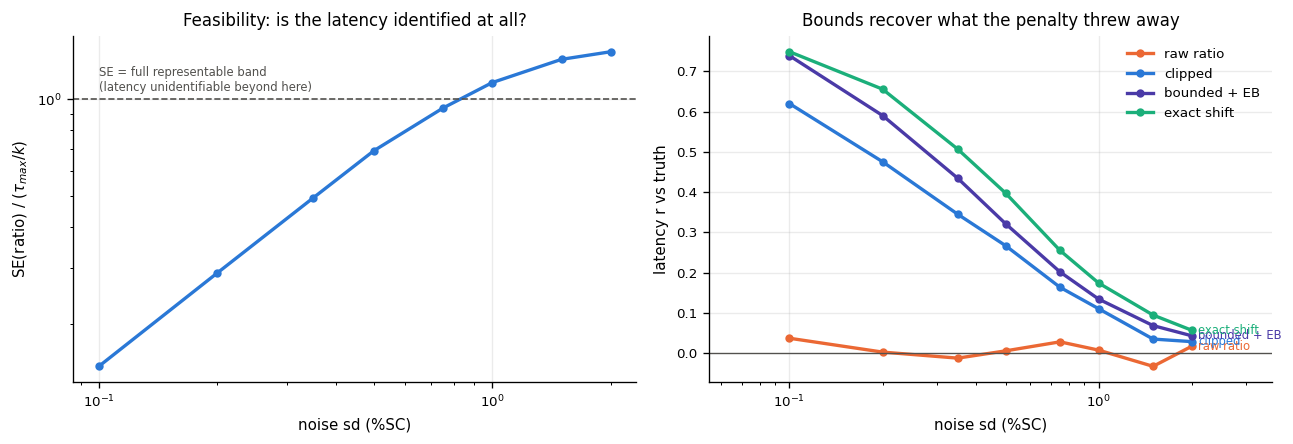

In [19]:
noise_grid = [0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0]
feas = []
for nsd in tqdm(noise_grid, desc='feasibility'):
    c = replace(cfg, noise_sd=nsd, n_voxels=100)
    s_ = simulate(c)
    cal_ = calibrate_ratio(s_, n_probe_trials=6)
    e_ = ratio_estimators(s_, cal_, c)
    r_ = fit_arms(s_, cal_, arms=('shift',))
    feas.append(dict(noise=nsd, se=np.median(e_['se_ratio']), rmax=e_['rmax'],
                     r_clip=score(s_['tau'], e_['clip'])['r'],
                     r_eb=score(s_['tau'], e_['eb'])['r'],
                     r_raw=score(s_['tau'], e_['raw'])['r'],
                     r_shift=score(s_['tau'], r_['shift']['tau'])['r']))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = [f['noise'] for f in feas]
ratio_se = [f['se'] / f['rmax'] for f in feas]

ax = axes[0]
ax.plot(x, ratio_se, color=C_CONE, lw=2, marker='o', ms=4)
ax.axhline(1.0, color=C_TRUTH, ls='--', lw=1)
ax.annotate('SE = full representable band\n(latency unidentifiable beyond here)',
            (x[0], 1.06), fontsize=7, color=C_TRUTH)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('noise sd (%SC)'); ax.set_ylabel(r'SE(ratio) / $(\tau_{max}/k)$')
ax.set_title('Feasibility: is the latency identified at all?')

ax = axes[1]
for key, col, lab in (('r_raw', C_RIDGE, 'raw ratio'), ('r_clip', C_CONE, 'clipped'),
                      ('r_eb', '#4a3aa7', 'bounded + EB'), ('r_shift', C_SHIFT, 'exact shift')):
    ax.plot(x, [f[key] for f in feas], color=col, lw=2, marker='o', ms=4, label=lab)
    ax.annotate(lab, (x[-1], feas[-1][key]), color=col, fontsize=7,
                xytext=(4, 0), textcoords='offset points', va='center')
ax.set_xscale('log'); ax.axhline(0, color=C_TRUTH, lw=0.8)
ax.set_xlabel('noise sd (%SC)'); ax.set_ylabel('latency r vs truth')
ax.set_title('Bounds recover what the penalty threw away')
ax.legend(loc='upper right'); ax.margins(x=0.2)
fig.tight_layout()

## 10. Getting the HRF right first — the two-stage recipe

Everything above fixed the voxel's shape to the SPM canonical. Real voxels do not
oblige, and the wiki already records the resolution: **select the shape at the
condition level, where single-trial noise averages out, then fix it and let trials
vary.** With the shape frozen within a voxel, it cannot absorb trial-to-trial
variation, so per-trial timing stays clean even where the voxel's *absolute* delay
was absorbed into its time-to-peak.

Two things this section settles:

1. **Can we take the temporal derivative of a library-selected HRF?** Yes —
   `np.gradient` is enough (measured corr 0.9995 against the analytic SPM
   derivative; the linearisation, not the derivative, is what limits validity).
   One trap: `np.gradient`'s sign convention is *opposite* SPM's derivative basis,
   so the calibration constant `k` comes out negative and the bound must be taken as
   `abs(tau_max / k)`. Clipping with a negative bound silently collapses every
   estimate to a constant.
2. **Does it beat exact shifting once both use the same per-voxel shape?**

Voxels now also get their own **absolute** timing offset, so the shape/delay
confound is actually exercised rather than assumed away.

In [20]:
from fastfuncstuff.design.shifted_hrf import (
    build_shape_library, select_shape_per_voxel, fit_shifted_hrf_per_voxel_shape,
)


def spmg2_from_shape(h, dt):
    # [h, dh/dt], L2-normalised.  NOTE: np.gradient's sign is opposite SPM's
    # derivative basis -- k below absorbs it, and the bound must use abs(k).
    d = np.gradient(np.asarray(h, float), dt)
    G = np.stack([np.asarray(h, float), d])
    return G / np.linalg.norm(G, axis=1, keepdims=True)


def simulate_multishape(cfg, shape_ids, lib, voxel_offset_sd=0.5):
    # Per-voxel HRF *and* per-voxel absolute timing offset, so shape selection
    # and delay genuinely compete (the confound this section is here to test).
    rng = np.random.default_rng(cfg.seed)
    device = torch.device(cfg.device)
    onsets, tau, amp, n_t = make_design(cfg, rng)
    n_vox = len(shape_ids)
    vox_off = rng.normal(0, voxel_offset_sd, size=n_vox)

    y = np.zeros((n_vox, n_t))
    for v in range(n_vox):
        h = lib[shape_ids[v]]
        ps = float(response_bank(np.array([cfg.lead_in]), h, cfg, n_t, device).abs().max())
        C = response_bank(onsets + tau + vox_off[v], h, cfg, n_t, device) / ps
        y[v] = (torch.as_tensor(amp, device=device, dtype=torch.float64) @ C).cpu().numpy()

    noise = generate_fmri_noise(
        tr=cfg.tr, duration_s=n_t * cfg.tr, matrix_size=(n_vox, 1),
        pink_exp=cfg.pink_exp, resp_strength=cfg.resp_strength,
        cardiac_strength=cfg.cardiac_strength, normalize=True, device=device,
        generator=torch.Generator(device=device).manual_seed(cfg.seed),
    ).reshape(-1, n_vox).T.cpu().numpy()[:, :n_t]
    y = y + cfg.noise_sd * noise
    if cfg.drift_sd > 0:
        P = legendre_polynomials(n_t, cfg.drift_degree)[:, 1:]
        y = y + rng.normal(0, cfg.drift_sd, size=(n_vox, P.shape[1])) @ P.T
    return dict(y=y, onsets=onsets, tau=tau, amp=amp, n_t=n_t, device=device,
                vox_off=vox_off, nuis=legendre_polynomials(n_t, cfg.polort))


def calibrate_k_shape(sim, cfg, G, n_probe=6, probe=np.linspace(-0.6, 0.6, 7)):
    Xn = torch.stack([response_bank(sim['onsets'], G[0], cfg, sim['n_t'], sim['device']),
                      response_bank(sim['onsets'], G[1], cfg, sim['n_t'], sim['device'])],
                     1).permute(2, 0, 1).reshape(sim['n_t'], -1).cpu().numpy()
    picks = np.linspace(0, cfg.n_trials - 1, n_probe).astype(int)
    rr = []
    for p in probe:
        vals = []
        for b in picks:
            ons = sim['onsets'].copy(); ons[b] += p
            yv = response_bank(ons, G[0], cfg, sim['n_t'], sim['device']).sum(0).cpu().numpy()
            bb = np.linalg.lstsq(Xn, yv, rcond=None)[0].reshape(-1, 2)
            vals.append(bb[b, 1] / bb[b, 0])
        rr.append(np.median(vals))
    return 1.0 / np.polyfit(probe, np.asarray(rr), 1)[0]


def fit_spmg2_shape(sim, cfg, G, k_cal, prior_sd_frac=0.5):
    X = torch.stack([response_bank(sim['onsets'], G[0], cfg, sim['n_t'], sim['device']),
                     response_bank(sim['onsets'], G[1], cfg, sim['n_t'], sim['device'])],
                    1).permute(2, 0, 1).reshape(sim['n_t'], -1)
    _, C = spmg_prior(cfg.canonical_std, cfg.derivative_std)
    fit = fit_basis_cone_prior(
        data=sim['y'], design_task=X, basis_functions=G,
        prior_mean=np.array([cfg.canonical_std, 0.0]), prior_cov=C,
        n_blocks=cfg.n_trials, nuisance=sim['nuis'], device=sim['device'])
    bt = fit.betas[:, :2 * cfg.n_trials].reshape(-1, cfg.n_trials, 2)
    ratio, bc = bt[..., 1] / bt[..., 0], bt[..., 0]
    Xf = np.concatenate([X.cpu().numpy(), sim['nuis']], 1)
    cdd = np.diag(np.linalg.pinv(Xf.T @ Xf))[1:2 * cfg.n_trials:2]
    resid = sim['y'] - fit.betas @ Xf.T
    sig2 = (resid ** 2).sum(1) / (sim['n_t'] - Xf.shape[1])
    w = np.maximum(bc ** 2, 1e-12) / np.maximum(sig2[:, None] * cdd[None, :], 1e-30)
    rmax = abs(cfg.tau_max / k_cal)            # sign lives in k_cal
    lam = 1.0 / (prior_sd_frac * rmax) ** 2
    rc = np.clip(ratio, -rmax, rmax)
    mu = (w * rc).sum(1, keepdims=True) / w.sum(1, keepdims=True)
    return k_cal * np.clip((w * ratio + lam * mu) / (w + lam), -rmax, rmax)


def rel(x):
    return x - x.mean(axis=-1, keepdims=True)

In [21]:
import time

lib_curves = get_hrf_library(mode='library', stim_duration=0.0,
                             microtime_dt=cfg.microtime_dt,
                             hrf_duration=cfg.hrf_duration).cpu().numpy()
shapes_lib, shape_labels = build_shape_library('library', cfg.microtime_dt, cfg.hrf_duration)
true_ids = np.array([2, 6, 10, 14, 18])

stage_rows = []
for nsd in (0.2, 0.5, 1.0):
    c = replace(cfg, n_voxels=250, n_trials=40, noise_sd=nsd)
    sids = np.repeat(true_ids, c.n_voxels // len(true_ids))
    s_ = simulate_multishape(c, sids, lib_curves)
    nuisT = torch.as_tensor(s_['nuis'], dtype=torch.float64, device=s_['device'])

    # ---- stage 1: shape selected at CONDITION level (all trials pooled) ----
    t0 = time.time()
    sel, _ = select_shape_per_voxel(s_['y'], [s_['onsets']], shapes_lib, cfg.microtime_dt,
                                    c.tr, nuisance=nuisT, durations=[c.stim_dur],
                                    device=s_['device'])
    sel = np.asarray(sel); t_sel = time.time() - t0
    ttp_true = np.array([np.argmax(lib_curves[k]) * cfg.microtime_dt for k in sids])
    ttp_sel = np.array([np.argmax(shapes_lib[k]) * cfg.microtime_dt for k in sel])

    # ---- stage 2a: SPMG2 on the SELECTED shape's numerical derivative ------
    t0 = time.time()
    tau_spmg = np.zeros((len(sids), c.n_trials))
    for k in np.unique(sel):
        m = sel == k
        G = spmg2_from_shape(shapes_lib[k], cfg.microtime_dt)
        sub = dict(s_); sub['y'] = s_['y'][m]
        tau_spmg[m] = fit_spmg2_shape(sub, c, G, calibrate_k_shape(s_, c, G))
    t_spmg = time.time() - t0

    # ---- stage 2b: EXACT SHIFT on the same selected shape ------------------
    t0 = time.time()
    shf, _ = fit_shifted_hrf_per_voxel_shape(
        s_['y'], [np.array([o]) for o in s_['onsets']], shapes_lib, cfg.microtime_dt, c.tr,
        shape_index=sel, nuisance=nuisT, tau_max=c.tau_max, tau_step=c.tau_step,
        durations=[c.stim_dur] * c.n_trials, n_sweeps=c.n_sweeps,
        delay_prior_sd=c.delay_prior_sd, device=s_['device'])
    t_shift = time.time() - t0

    # ---- stage 2c: SPMG2 on the WRONG (canonical) shape, as the control ----
    Gc = spmg2_from_shape(shapes_lib[len(shapes_lib) // 2], cfg.microtime_dt)
    tau_canon = fit_spmg2_shape(s_, c, Gc, calibrate_k_shape(s_, c, Gc))

    for nm, e, t in (('SPMG2 canonical shape', tau_canon, np.nan),
                     ('SPMG2 selected shape', tau_spmg, t_spmg),
                     ('exact shift, selected', shf.delays, t_shift)):
        r_, sl_ = score(rel(s_['tau'])[None, :], rel(e))['r'], \
                  score(rel(s_['tau'])[None, :], rel(e))['slope']
        stage_rows.append(dict(noise=nsd, arm=nm, r=r_, slope=sl_, t=t,
                               ttp_r=float(np.corrcoef(ttp_true, ttp_sel)[0, 1]),
                               ttp_err=float(np.median(np.abs(ttp_sel - ttp_true))),
                               t_sel=t_sel))

hdr = f"{'noise':>6s} {'arm':24s} {'REL r':>7s} {'slope':>7s} {'fit s':>7s}"
print(f"shape selection: TTP r = {stage_rows[0]['ttp_r']:+.3f}, "
      f"median |err| = {stage_rows[0]['ttp_err']:.2f}s, {stage_rows[0]['t_sel']:.2f}s\n")
print(hdr); print('-' * len(hdr))
for r_ in stage_rows:
    print(f"{r_['noise']:6.2f} {r_['arm']:24s} {r_['r']:+7.3f} {r_['slope']:+7.3f} "
          f"{r_['t']:7.2f}")

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

shape selection: TTP r = +0.931, median |err| = 0.20s, 0.04s

 noise arm                        REL r   slope   fit s
-------------------------------------------------------
  0.20 SPMG2 canonical shape     +0.311  +0.426     nan
  0.20 SPMG2 selected shape      +0.712  +0.812   14.49
  0.20 exact shift, selected     +0.772  +0.589    2.73
  0.50 SPMG2 canonical shape     +0.210  +0.230     nan
  0.50 SPMG2 selected shape      +0.465  +0.458   17.67
  0.50 exact shift, selected     +0.515  +0.396    2.94
  1.00 SPMG2 canonical shape     +0.105  +0.091     nan
  1.00 SPMG2 selected shape      +0.227  +0.190   18.84
  1.00 exact shift, selected     +0.251  +0.189    2.76


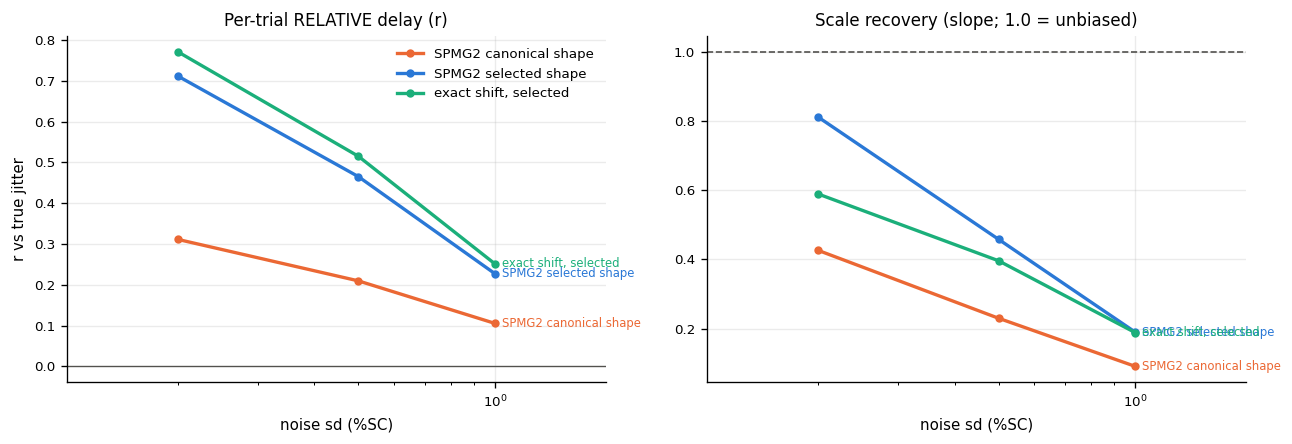

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
arms10 = ['SPMG2 canonical shape', 'SPMG2 selected shape', 'exact shift, selected']
cols10 = {'SPMG2 canonical shape': C_RIDGE, 'SPMG2 selected shape': C_CONE,
          'exact shift, selected': C_SHIFT}
noises = sorted({r['noise'] for r in stage_rows})

for ax, metric, ttl in ((axes[0], 'r', 'Per-trial RELATIVE delay (r)'),
                        (axes[1], 'slope', 'Scale recovery (slope; 1.0 = unbiased)')):
    for a in arms10:
        ys = [next(r[metric] for r in stage_rows if r['arm'] == a and r['noise'] == n)
              for n in noises]
        ax.plot(noises, ys, color=cols10[a], lw=2, marker='o', ms=4, label=a)
        ax.annotate(a, (noises[-1], ys[-1]), color=cols10[a], fontsize=7,
                    xytext=(4, 0), textcoords='offset points', va='center')
    ax.set_xscale('log'); ax.set_xlabel('noise sd (%SC)'); ax.set_title(ttl)
    ax.margins(x=0.35)
axes[0].set_ylabel('r vs true jitter'); axes[0].axhline(0, color=C_TRUTH, lw=0.8)
axes[1].axhline(1.0, color=C_TRUTH, lw=1, ls='--')
axes[0].legend(loc='upper right')
fig.tight_layout()

Getting the shape right is what unlocks the derivative route — but exact shifting,
handed the *same* shape, still edges it on `r` while running faster. The one axis
SPMG2 wins is **slope** (less compression), and that is a `delay_prior_sd` dial on the
shift side rather than a structural advantage: loosening it trades `r` for scale.

## 11. One model, not two — amplitude and delay from a single fit

It is tempting to run SPMG2 + cone for amplitude and the shift model for latency. That
is **wrong**, and not only on tidiness grounds: amplitude depends on the shape too, so
the two passes would estimate the two halves of one answer under two different forward
models — one canonical-shaped, one per-voxel-shaped.

No new model is needed. `fit_shifted_hrf_per_voxel_shape` already *is* the informed
single model:

1. each voxel's shape is selected from **condition-pooled** blocks (1 amplitude DOF
   instead of n_trials, so the shape comparison is well determined);
2. then per-trial **amplitude and delay are fit jointly** on that fixed shape —
   amplitude an exact linear solve given delay (variable projection), delay a
   box-bounded coordinate shrunk toward the voxel's own mean.

Both outputs come out of one call. The cell below checks the amplitude half, and tests
the obvious next idea — bounding amplitude with a condition-level estimate too.

In [23]:
amp_rows = []
for nsd in (0.2, 0.5, 1.0):
    c = replace(cfg, n_voxels=250, n_trials=40, noise_sd=nsd)
    sids = np.repeat(true_ids, c.n_voxels // len(true_ids))
    s_ = simulate_multishape(c, sids, lib_curves)
    nuisT = torch.as_tensor(s_['nuis'], dtype=torch.float64, device=s_['device'])
    sel, _ = select_shape_per_voxel(s_['y'], [s_['onsets']], shapes_lib, cfg.microtime_dt,
                                    c.tr, nuisance=nuisT, durations=[c.stim_dur],
                                    device=s_['device'])
    sel = np.asarray(sel)
    shf, _ = fit_shifted_hrf_per_voxel_shape(
        s_['y'], [np.array([o]) for o in s_['onsets']], shapes_lib, cfg.microtime_dt, c.tr,
        shape_index=sel, nuisance=nuisT, tau_max=c.tau_max, tau_step=c.tau_step,
        durations=[c.stim_dur] * c.n_trials, n_sweeps=c.n_sweeps,
        delay_prior_sd=c.delay_prior_sd, device=s_['device'])

    # amplitudes -> %SC of an isolated boxcar response of that voxel's own shape
    psc = np.array([float(response_bank(np.array([c.lead_in]), shapes_lib[k], c,
                                        s_['n_t'], s_['device']).abs().max())
                    for k in range(len(shapes_lib))])
    A = shf.amplitudes * psc[sel][:, None]
    Acond = A.mean(1, keepdims=True)          # the voxel's condition-level amplitude
    v = np.maximum(A.var(1, keepdims=True), 1e-12)

    cands = [('raw single-trial A', A)]
    for f in (1.0, 0.5):                      # prior sd as a FRACTION of A_cond
        lam = 1.0 / np.maximum(np.abs(Acond) * f, 1e-6) ** 2
        cands.append((f'shrink to A_cond (f={f})', ((1 / v) * A + lam * Acond) / (1 / v + lam)))
    for nm, e in cands:
        sc_ = score(s_['amp'], e)
        amp_rows.append(dict(noise=nsd, arm=nm, **sc_))

hdr = f"{'noise':>6s} {'estimator':26s} {'r':>7s} {'slope':>7s} {'rmse':>7s}"
print(hdr); print('-' * len(hdr))
for r_ in amp_rows:
    print(f"{r_['noise']:6.2f} {r_['arm']:26s} {r_['r']:+7.3f} {r_['slope']:+7.3f} "
          f"{r_['rmse']:7.3f}")

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shape selection:   0%|          | 0/20 [00:00<?, ?shape/s]

  Shift fit per shape:   0%|          | 0/20 [00:00<?, ?shape/s]

 noise estimator                        r   slope    rmse
---------------------------------------------------------
  0.20 raw single-trial A          +0.920  +0.983   0.259
  0.20 shrink to A_cond (f=1.0)    +0.912  +0.782   0.256
  0.20 shrink to A_cond (f=0.5)    +0.880  +0.488   0.345
  0.50 raw single-trial A          +0.668  +0.973   0.653
  0.50 shrink to A_cond (f=1.0)    +0.633  +0.721   0.567
  0.50 shrink to A_cond (f=0.5)    +0.512  +0.420   0.559
  1.00 raw single-trial A          +0.363  +0.930   1.390
  1.00 shrink to A_cond (f=1.0)    +0.287  +0.526   1.066
  1.00 shrink to A_cond (f=0.5)    +0.170  +0.257   0.980


**Raw single-trial amplitude is already unbiased** (slope ≈ 1.0 at every noise level),
and shrinking toward the condition level never improves `r` — it only trades slope for
RMSE, which is the "predict the mean" win, not better recovery. That holds even when the
true trial-to-trial spread is small (set `amp_spread` low and re-run to check).

The reason single-trial amplitudes "go stupid" in SPMG2 is therefore **the second
column**, not single-trial-ness. Two columns per trial let amplitude and derivative
trade against each other in an ill-conditioned design. Remove the derivative and put
the timing into a bounded coordinate, and the conditioning problem simply goes away —
so amplitude needs no bound of its own.

## 12. Verdict, and what to run

### Findings

1. **Bounds beat penalties.** A penalty makes the runaway region expensive; a bound
   makes it unreachable. The cone's angular penalty *saturates*
   ($\operatorname{pen}\to1$), so it cannot restrain an unbounded ratio — raw SPMG2
   latency scores r ≈ 0, the same fit bounded scores far better.
2. **Latency in SPMG2 lives in a ratio; in the shift model it is a coordinate.** That
   single structural difference is the whole story.
3. **Shape first, at the condition level, is essential** — it takes derivative-based
   latency from r = 0.11 to r = 0.72, and it is what makes amplitude meaningful too.
4. **One fit gives both.** With the shape right and delay bounded, single-trial
   amplitude is well conditioned (r ≈ 0.93, slope ≈ 0.99 at tSNR 500) and needs no
   prior of its own.
5. **There is a computable floor.** When SE(ratio) approaches $\tau_{max}/k$, per-trial
   latency is unidentifiable and every estimator returns the prior.

### The command

```bash
ffs_fitbasis -input run*.nii.gz -events run*_events.tsv \
    -parametrization shift -shift-shapes library -single-trials \
    -tau-max 2.0 -tau-step 0.25 -delay-prior-sd 0.75 -shift-sweeps 4 \
    -polort 4 -xval-r2 -prefix sub01
```

One pass. `-shift-shapes` runs the condition-level shape stage internally, then fits
per-trial amplitude and delay on the selected curve. Note that `-parametrization shift`
**ignores `-model` and `-reg`** — it has no basis coefficients, so there is no prior to
apply; the CLI warns if you pass them.

Use `-model SPMG2 -reg cone` only if you want amplitudes *without* the delay model at
all — it is faster, but its amplitudes were worse here (r 0.58 vs 0.93).

| output | meaning |
|---|---|
| `_shift_amplitude_<cond>` | per-trial amplitude (4-D, time = trial) |
| `_shift_delay_dev_<cond>` | **per-trial deviation from the voxel's own mean** — the unconfounded timing quantity |
| `_shift_shape_ttp` | time-to-peak of the selected curve — the carrier of *voxel-level* timing |
| `_shift_mean_timing` | TTP + mean delay = mean response timing |
| `_shift_delay_<cond>` | raw delay — **residual** timing only when shapes are on |
| `_shift_xvalr2`, `_xvalr2_delay_gain` | the only honest evidence; in-sample `r2 − r2_tau0` proves nothing |

**Knobs that matter:** `-tau-max` must contain the real spread (truth outside it does
not clamp gracefully — the amplitude solve compensates with alternating signed
amplitudes). `-delay-prior-sd` is the bias/variance dial: 0.75 maximises `r` but
compresses delay scale to ≈0.6; ≈1.5 gives near-unbiased scale at slightly lower `r`.
For one clean **absolute** delay map, drop `-shift-shapes` and pass a single
`-shift-hrf` so all timing is forced into the delay parameter.

**Caveat:** all of this is simulation. The one real-data run at this scale crashed in
cross-validation before producing the map that would settle it.

### See also
- `../fmri_wiki/notes/ffs_fitbasis latency rework.md`
- `fastfuncstuff/design/shifted_hrf.py:fit_shifted_hrf_per_voxel_shape`
- `fastfuncstuff/design/flobs.py:fit_basis_cone_prior`